# A tutorial for NuQuLib 

In this notebook, we will explore the functionalities of NuQuLib, a quantum computing library designed for simulating nuclear systems. We will cover the following topics:

1. Hamiltonian mapping
   - a. Jordan-Wigner mapping of nuclear Hamiltonians
   - b. Pairing Hamiltonian
   - c. comparison with Chemical Hamiltonians
2. VQE with UCC ansatz
3. Examples of (E-)FTQC algorithms: QPE for small systems

## Installation and defining some helper functions
 
After a certain version for Python and pip (around 3.11),
the Python community proposed [PEP 668](https://peps.python.org/pep-0668/) for managing python packages.
Users are now strongly recommended to use virtual environments to avoid conflicts between packages and conflicts with the system itself.
Specifically, it is recommended to create a virtual environment for each project, not to break your "carefully raised" python environment.

You can create a virtual environment with the following command:

```bash
$python3 -m venv name_of_your_env
```

Then, you can activate the virtual environment with the following command:

```bash
$source path_to_your_env/bin/activate
```

After activating the virtual environment, you can install the required packages with the following command:

```bash
$pip install -e -e /path_to_NuQuLib
```

If you want to use GPU acceleration, please refer to the Qiskit documentation for installing the appropriate version of `qiskit-aer`.
You may need to remove the existing `qiskit-aer` package before installing the GPU version `qiskit-aer-gpu`.

In [ ]:
import seaborn as sns
import re
from nuqulib import *

def cnuc(nuc): # convert "2H" to "$^{2}$H"
    A = re.findall(r'\d+', nuc)
    element = nuc.replace(A[0], "")
    return f"$^{{{A[0]}}}${element}"

# My color palette
cols = sns.color_palette("deep", 10)
cols[0], cols[2] = cols[2], cols[0] 
cols[1], cols[3] = cols[3], cols[1] 

int_file_path = "tests/interaction_file/"
device_type = "CPU" # "CPU" or "GPU"

/Users/sotair/nuqulib_venv/lib/python3.12/site-packages/pennylane/__init__.py:212: PennyLaneDeprecationWarning: PennyLane v0.44 has dropped maintainence support for NumPy < 2.0.0. You have version 1.26.4 installed. Future versions of PennyLane will not work with NumPy<2.0. Please consider upgrading NumPy using `python -m pip install numpy --upgrade`. 
  warnings.warn(


## 1. Hamiltonian mapping

### a) Jordan-Wigner mapping of nuclear Hamiltonians

In the following, we demonstrate the usage of the `NuQuLib` package by taking smaller systems with only a few (valence) nucleons.

First, we read `ckpot` effective interaction for 0p shell (p1/2 and p3/2 orbitals on top of 4He core) and map it to the qubit Hamiltonian using Jordan-Wigner transformation.

NuQuLib allows to read the interaction files for NN and 3N interactions in e.g. `snt` (`kshell.snt` in NuHamil code) format.
One can check the mapping is correct by comparing the energy of the ground state of fully occupied systems in the specified model space.

In the following, we will see both valence (p, sd, pf) and NCSM (emax=0, 1) cases give correct results.

#### valence space

We will consider the following fully occupied systems in the valence shell model spaces:

- 16O in p shell
- 40Ca in sd shell


In [2]:
fns = ["ckpot.snt", "usdb.snt"]
ZNs = [ (8, 8), (20, 20) ]

for idx in range(len(fns)):
    filename_snt = int_file_path + fns[idx]
    print("filename_snt:", filename_snt)
    Z, N = ZNs[idx]
    hamil = Hamiltonian(filename_snt, Z, N)

    mapping_method = "JordanWigner"
    hamil.get_mscheme_H(opform=True)
    H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)
    H_1b = H_1b_p + H_1b_n

    n_qubits = hamil.n_qubits
    qc = QuantumCircuit(n_qubits)
    qc.x(range(n_qubits))  # prepare all qubits in |1> state

    # measurement of Hamiltonian
    estimator = StatevectorEstimator()
    job = estimator.run([(qc, H_1b), (qc, H_pp), (qc, H_nn), (qc, H_pn)])
    results = job.result()
    E_1b, E_pp, E_nn, E_pn = [ results[i].data.evs for i in range(len(results))]
    E_total = E_1b + E_pp + E_nn + E_pn 
    print("Etot", E_total, "E_1b: ", E_1b, "<pp>", E_pp, "<nn>", E_nn, "<pn>", E_pn)


filename_snt: tests/interaction_file/ckpot.snt


0it [00:00, ?it/s]

# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...



100%|██████████| 262/262 [00:00<00:00, 2549669.72it/s]


Removing redundant terms... len= 3376


...

# of H_m terms, 1b: 24, 2b pp: 620, nn: 620, pn: 3618 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using JordanWigner...


100%|██████████| 2884/2884 [00:00<00:00, 4260786.45it/s]


Removing redundant terms... len= 41472


41472it [00:00, 156520.58it/s]


Finally, len =>  9513
Etot -279.9607012333838 E_1b:  -43.04640000000002 <pp> -15.600464041796151 <nn> -15.600464041796151 <pn> -205.71337314979147


#### NCSM (No-core shell model) space

NN interaction is the so-called EM500 with SRG (1.8 fm^{-1} cutoff) and HO basis with hw=20 MeV and emax=1.
The 3N interaction called local-nonlocal (lnl) interaction is used.

One should keep in mind that the results will change depending on the choice of the interaction and the settings to generate the Hamiltonian.
Within these settings, the ground state energy of ${}^{16}\text{O}$ would be -131.83565 MeV.

In [23]:
emax = 1
filename_snt = int_file_path + "TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax1_e2max2.kshell.snt"
fn_3NF = int_file_path + "ThBME_lnl_ms1_2_1.readable.txt"
Z = proton_number  = N = neutron_number = 8

hamil = Hamiltonian(filename_snt, Z, N, ncsm=True, verbose=False, emax_truncate=emax,
                    e3max=emax, fn_3NF=fn_3NF)
mapping_method = "JordanWigner"
hamil.get_mscheme_H(opform=True)
H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform(mapping_method)
H_1b = H_1b_p + H_1b_n

Hamil_NCSM_NN = H_1b + H_pp + H_nn + H_pn
hamil.set_mscheme_3NF()
H_3b = hamil.mapping_3NF_Mscheme()
Hamil_NCSM_NN3NF = Hamil_NCSM_NN + H_3b

n_qubits = hamil.n_qubits
qc = QuantumCircuit(n_qubits)
qc.x(range(n_qubits))  # prepare all qubits in |1> state

# measurement of Hamiltonian
estimator = StatevectorEstimator()
job = estimator.run([(qc, H_1b), (qc, H_pp), (qc, H_nn), (qc, H_pn), (qc, H_3b)])
results = job.result()
E_1b, E_pp, E_nn, E_pn, E_3n = [ results[i].data.evs for i in range(len(results))]
E_total = E_1b + E_pp + E_nn + E_pn + E_3n
print("Etot", E_total, "E(NN)", E_1b + E_pp + E_nn + E_pn)
print("E_1b: ", E_1b, "<pp>", E_pp, "<nn>", E_nn, "<pn>", E_pn, "<3b>", E_3n)

print("Example of NN+3NF terms:")
print(H_3b[:100:20])

Setting up 3NF matrix elements in mscheme...


100%|██████████| 408/408 [00:00<00:00, 6512.99it/s]


Total number of 3NF matrix elements in M-scheme 15984


100%|██████████| 15984/15984 [00:00<00:00, 454723.84it/s]

# of H_m terms, 1b: 16, 2b pp: 83, nn: 83, pn: 456 v3b 2128


...

100%|██████████| 408/408 [00:00<00:00, 4028.72it/s]


Total number of 3NF matrix elements in M-scheme 15984


100%|██████████| 2128/2128 [00:00<00:00, 3158343.56it/s]

Encoding 3NF in Jordan-Wigner mapping... # of 3NF terms: 2128


Removing redundant terms... len= 53632 => 2339
3NF mapping done in 0.95 sec.  2469.69 terms/sec
Etot -131.83565105910458 E(NN) -148.36878574000022
E_1b:  337.5 <pp> -53.04027524000001 <nn> -70.00286417999999 <pn> -362.8256463200002 <3b> 16.53313468089563
Example of NN+3NF terms:
SparsePauliOp(['IIIIIIIIIIIIIIII', 'IIIIIIYXIIIIXYII', 'IIIIIIYYIIIIYYZI', 'IIIIIXXIIIIIIYYI', 'IIIIXZXIIIIIIYIY'],
              coeffs=[ 2.06664184+0.j, -0.03543338+0.j, -0.01771669+0.j, -0.03105602+0.j,
 -0.02241239+0.j])


### b) Pairing Hamiltonian (JW)

Pairing Hamiltonian is a simplified model of the nuclear interaction or a simplified model of BCS pairing. The Hamiltonian with a global pairing interaction is given by

$$
H = \sum_{i} \epsilon_i a_i^{\dagger} a_i - \frac{g}{4} \sum{i,j} a_i^{\dagger} a_{\bar{i}}^{\dagger} a_{\bar{j}} a_j
$$

where $a_i^{\dagger}$ and $a_i$ are the creation and annihilation operators for the nucleon in the $i$-th orbital, $\epsilon_i$ is the single-particle energy of the $i$-th orbital, $g$ is the pairing strength, and $\bar{i}$ is the time-reversed orbital of $i$.

In [4]:
Norb = 12
Nocc = 6
gval = 0.33
hamil = PairingHamiltonian(Norb, Nocc, gval)
Hamil_Pairing = hamil.encoding()

# Make a time evolution operator U = exp(-iHt)
delta_t = 0.1
Unitary_P = PauliEvolutionGate(Hamil_Pairing, delta_t, synthesis=SuzukiTrotter(order=1,reps=1))
print("U:", Unitary_P)

# Make a quantum circuit (1 ancilla + target qubits)
qc = QuantumCircuit(Norb+1)
Unitary_P = Unitary_P.control(1)
qc.append(Unitary_P, range(Norb+1))
qc = qc.decompose(reps=5)
print("# of gates, raw circuit:", qc.count_ops())

U: Instruction(name='PauliEvolution', num_qubits=12, num_clbits=0, params=[0.1])
# of gates, raw circuit: OrderedDict({'u': 1345, 'cx': 552})


### c) Chemical Hamiltonians 

According to the Pennylane documentation [here](https://docs.pennylane.ai/en/stable/introduction/chemistry.html), `qchem` module provides molecular Hamiltonians.

One can specify the molecule by its symbols and geometry, and then the Hamiltonian can be generated using the `qml.qchem.molecular_hamiltonian` function.

Similarly, Qiskit provides molecular Hamiltonians via e.g. `qiskit_nature` module.

In [5]:
symbols = ["Li", "H"]
geometry = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 2.969280527]])
molecule = qml.qchem.Molecule(symbols, geometry)
H, qubits = qml.qchem.molecular_hamiltonian(
    molecule,
    active_electrons=2,
    active_orbitals=5,
)
def circuit(params):
    qml.ApproxTimeEvolution(H, time=0.1, n=1)
    return [qml.expval(qml.PauliZ(i)) for i in range(qubits)]

dev = qml.device("default.qubit", wires=qubits)
params = np.random.rand(qubits)
compiled_qnode = qml.compile(
    qml.QNode(circuit, device=dev),
    basis_set=["CNOT", "RX", "RY", "RZ"])

spec = qml.specs(compiled_qnode)(params)

print("qubits:", qubits, "Gates:", dict(spec["resources"].gate_types))

qubits: 10 Gates: {'RZ': 1437, 'RX': 1186, 'CNOT': 2356}


## 2. VQE with UCC ansatz



**Note: This part should be run with old versions of Qiskit (such as 1.3).**

We should note that some libraries like `qiskit-nature` are not compatible with Qiskit 2.x yet. These things can happen due to rapid development of Qiskit.


The key components of the VQE algorithm is to prepare a trial wavefunction, given as parametrized quantum circuit, and to minimize the expectation value of the Hamiltonian with respect to this wavefunction.

We adopt the unitary coupled cluster (UCC) ansatz here.

To start rather arbitrarily, let us define a function to generate excitation operators on top of a naive filling configuration. This will be referred in the UCC class, so it should be defined in this manner.

In [2]:
from qiskit_algorithms.optimizers import SLSQP
from qiskit_algorithms.minimum_eigensolvers import VQE
from qiskit_nature.second_q.circuit.library.ansatzes import UCC
from qiskit.primitives import Estimator

def custom_excitation_list(num_spatial_orbitals, num_particles):
    global hole_p, particle_p, hole_n, particle_n
    my_custom_excitations = [ ]
    ## Single excitations
    for h_p in hole_p:
        for p_p in particle_p:
            my_custom_excitations.append( ((h_p,), (p_p,)) )
    for h_n in hole_n:
        for p_n in particle_n:
            my_custom_excitations.append( ((h_n,), (p_n,)) )

    ## pp doubles
    for h_p_1 in hole_p:
        for h_p_2 in hole_p:
            if h_p_1 == h_p_2: continue
            for p_p_1 in particle_p:
                for p_p_2 in particle_p:
                    if p_p_1 == p_p_2: continue
                    my_custom_excitations.append( ((h_p_1, h_p_2), (p_p_1, p_p_2)) )
    ## nn doubles
    for h_n_1 in hole_n:
        for h_n_2 in hole_n:
            if h_n_1 == h_n_2: continue
            for p_n_1 in particle_n:
                for p_n_2 in particle_n:
                    if p_n_1 == p_n_2: continue
                    my_custom_excitations.append( ((h_n_1, h_n_2), (p_n_1, p_n_2)) )
    ## pn doubles
    for h_p in hole_p:
        for h_n in hole_n:
            for p_p in particle_p:
                for p_n in particle_n:
                    my_custom_excitations.append( ((p_p, p_n), (h_p, h_n)) )
    return my_custom_excitations

### 6He (2n on 0p shell)

Egs (J=0) =  -3.90981 MeV

In [5]:
np.random.seed(42)  
fn = int_file_path+"ckpot.snt"
Z = 2; N = 4
Hamil_Shellmodel, H_JW, proton_qubits, neutron_qubits = get_Hamiltonian(fn, Z, N)
n_qubits = Hamil_Shellmodel.n_qubits
mapper = JordanWignerMapper()

# Define the initial state&UCC ansatz
init_state = QuantumCircuit(n_qubits)
init_state.x(9); init_state.x(10); hole_p = [ ]; hole_n = [9, 10]

particle_p = [q for q in proton_qubits if q not in hole_p]
particle_n = [q for q in neutron_qubits if q not in hole_n]

vqe_ansatz = UCC(
    n_qubits//2,
    num_particles=(Z, N),
    initial_state=init_state,
    qubit_mapper = mapper,
    preserve_spin=True,
    reps=1,
    excitations = custom_excitation_list
)

optimizer = SLSQP(maxiter=200)
print("Number of parameters: ", vqe_ansatz.num_parameters)
print("vqe.excitations: ", vqe_ansatz._excitation_list)
print("Gate counts:", vqe_ansatz.decompose(reps=5).count_ops())

def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)

counts = []
values = []
vqe = VQE(Estimator(), vqe_ansatz, optimizer=optimizer, callback=store_intermediate_result)
result = vqe.compute_minimum_eigenvalue(operator=H_JW)
print(f"E(VQE) = {result.eigenvalue.real:.5f}")

0it [00:00, ?it/s]

# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using Jordan-Wigner...



100%|██████████| 262/262 [00:00<00:00, 1907825.78it/s]


Removing redundant terms... len= 3376


3376it [00:00, 106366.77it/s]

Finally, len =>  777
Number of parameters:  32
vqe.excitations:  [((9,), (6,)), ((9,), (7,)), ((9,), (8,)), ((9,), (11,)), ((10,), (6,)), ((10,), (7,)), ((10,), (8,)), ((10,), (11,)), ((9, 10), (6, 7)), ((9, 10), (6, 8)), ((9, 10), (6, 11)), ((9, 10), (7, 6)), ((9, 10), (7, 8)), ((9, 10), (7, 11)), ((9, 10), (8, 6)), ((9, 10), (8, 7)), ((9, 10), (8, 11)), ((9, 10), (11, 6)), ((9, 10), (11, 7)), ((9, 10), (11, 8)), ((10, 9), (6, 7)), ((10, 9), (6, 8)), ((10, 9), (6, 11)), ((10, 9), (7, 6)), ((10, 9), (7, 8)), ((10, 9), (7, 11)), ((10, 9), (8, 6)), ((10, 9), (8, 7)), ((10, 9), (8, 11)), ((10, 9), (11, 6)), ((10, 9), (11, 7)), ((10, 9), (11, 8))]


Gate counts: OrderedDict({'u3': 2400, 'cx': 1480, 'u': 1010})


/var/folders/w4/qfsp76x90732_cjtryhq_19w0000gn/T/ipykernel_52041/2111427068.py:38: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), vqe_ansatz, optimizer=optimizer, callback=store_intermediate_result)


E(VQE) = -3.90981


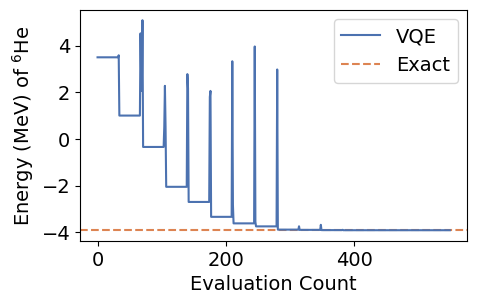

In [8]:
counts_vqe = list(counts)
values_vqe = list(values)
Eexact =  -3.90981
fig = plt.figure(figsize=(5, 3))
plt.plot(values_vqe, color=cols[2], label='VQE', zorder=1)
plt.axhline(y=Eexact, color=cols[3], linestyle='--', label='Exact', zorder=0)
plt.xlabel('Evaluation Count')
plt.ylabel('Energy (MeV) of $^6$He')
plt.legend()
plt.rcParams["font.size"] = 14
plt.savefig("vqe_energy_6He.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()

### 6Li (p-n on 0p shell)

Egs = -5.43299 MeV (J=1)

In [9]:
np.random.seed(42)  

fn = int_file_path + "ckpot.snt"
Z = N = 3
Hamil_Shellmodel, H_JW, proton_qubits, neutron_qubits = get_Hamiltonian(fn, Z, N)
n_qubits = Hamil_Shellmodel.n_qubits
mapper = JordanWignerMapper()

# Define the initial state&UCC ansatz
init_state = QuantumCircuit(n_qubits)
init_state.x(3); init_state.x(10); hole_p = [3]; hole_n = [10]

particle_p = [q for q in proton_qubits if q not in hole_p]
particle_n = [q for q in neutron_qubits if q not in hole_n]

vqe_ansatz = UCC(
    n_qubits//2,
    num_particles=(Z, N),
    initial_state=init_state,
    qubit_mapper = mapper,
    preserve_spin=True,
    reps=1,
    excitations = custom_excitation_list
)

optimizer = SLSQP(maxiter=200)
print("Number of parameters: ", vqe_ansatz.num_parameters)


def store_intermediate_result(eval_count, parameters, mean, std):
    counts.append(eval_count)
    values.append(mean)

counts = []
values = []
vqe = VQE(Estimator(), vqe_ansatz, optimizer, callback=store_intermediate_result)
vqe.initial_point = np.random.normal(0, 0.1, vqe_ansatz.num_parameters)
vqe_result = vqe.compute_minimum_eigenvalue(H_JW)
binding_energy = vqe_result.optimal_value
#print("Parameters: ", vqe_result.optimal_point)

print("E(VQE) = ", binding_energy)
print("Gate counts:", vqe_ansatz.decompose(reps=5).count_ops())

0it [00:00, ?it/s]

# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using Jordan-Wigner...



100%|██████████| 262/262 [00:00<00:00, 2486216.40it/s]


Removing redundant terms... len= 3376


3376it [00:00, 106114.09it/s]
/var/folders/w4/qfsp76x90732_cjtryhq_19w0000gn/T/ipykernel_52041/2957450637.py:36: DeprecationWarning: The class ``qiskit.primitives.estimator.Estimator`` is deprecated as of qiskit 1.2. It will be removed no earlier than 3 months after the release date. All implementations of the `BaseEstimatorV1` interface have been deprecated in favor of their V2 counterparts. The V2 alternative for the `Estimator` class is `StatevectorEstimator`.
  vqe = VQE(Estimator(), vqe_ansatz, optimizer, callback=store_intermediate_result)


Finally, len =>  777
Number of parameters:  35
E(VQE) =  -5.432985327197499
Gate counts: OrderedDict({'u3': 2520, 'cx': 2080, 'u': 1062})


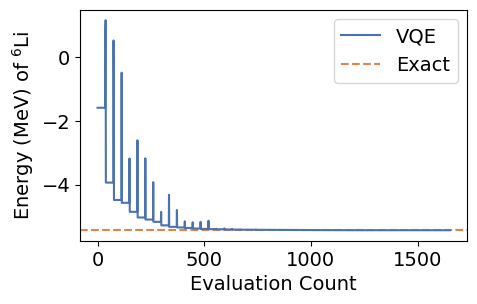

In [10]:
counts_vqe = list(counts)
values_vqe = list(values)
Egs = -5.43299
Eex1 = -5.008799945408569
fig = plt.figure(figsize=(5, 3))
plt.plot(values_vqe, color=cols[2], label='VQE', zorder=1)
plt.axhline(y=Egs, color=cols[3], linestyle='--', label='Exact', zorder=0)
plt.xlabel('Evaluation Count')
plt.ylabel('Energy (MeV) of $^6$Li')
plt.legend()
plt.rcParams["font.size"] = 14
plt.savefig("vqe_energy_6Li.pdf", bbox_inches='tight', pad_inches=0.01)
plt.show()

## 3. Examples of (E-)FTQC algorithms: QPE for small systems

In the following, we demonstrate the usage of NuQuLib package to perform Quantum Phase Estimation (QPE) algorithm for small nuclear systems.

The first example is 12C on 0p shell with CKpot interaction.

The spectrum is obtained by brute-force diagonalization for comparison,
and one can see that QPE reproduces the exact spectrum within certain accuracy depending on the number of ancilla qubits and Trotter steps.

In [24]:
def plot_spectrum(n_ancilla, dt, target, nuc, Energy_list, Ens_exact, p_threshold=1e-6):
    if target == "NN":
        int_type = "NN-only" 
    elif target == "NN3NF":
        int_type = "NN+3NF"
    elif target == "valence":
        int_type = "Valence-space"
    else:
        int_type = ""

    fn_plot = "qpe_results/qpe_results_" + target + "_" + nuc + f"_Na{n_ancilla}.pdf"
    fig = plt.figure(figsize=(5,3))
    ax = fig.add_subplot(1,1,1)
    #ax.set_yscale("log")
    ax.set_xlabel("Energy (MeV)")
    ax.set_ylabel("Probability Density")
    barwidth = abs(2 * np.pi / (delta_t * 2**n_ancilla) * 0.8)
    ax.bar([energy for energy, p in Energy_list], 
            [p for energy, p in Energy_list], 
            width=barwidth, color=cols[0], alpha=0.8, zorder=100)

    for E in Ens_exact:
        ax.axvline(E, color="k", linestyle="dashed", alpha=0.8, zorder=0)
    target = "NN-only" if target == "NN" else "NN+3NF"
    ax.text(0.95, 0.95, cnuc(nuc)+": " + int_type, transform=ax.transAxes, fontsize=14, va="top", ha="right",
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.9, edgecolor="gray"))
    plt.savefig(fn_plot, bbox_inches='tight', pad_inches=0.05)
    plt.close()


In [25]:
# Valence case, specify target
target = "valence"
filename_snt = int_file_path+"ckpot.snt"
Zc = Nc = 2 

nuc = "C12"
Z = N = 6
qrange = [2, 3, 4, 5, 8, 9, 10, 11] # for C12

nuc = "C14"
Z = 6; N = 8
qrange = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11]
delta_t = 0.07

target_parity = 1 

print("Emin:", 2 * np.pi / (-delta_t))

Emin: -89.7597901025655


In [19]:
emax = e3max = 1
filename_snt = int_file_path + f"TwBME-HO_NN-only_N3LO_EM500_srg1.8_hw20_emax{emax}_e2max{emax*2}.kshell.snt"
fn_3NF = int_file_path + "ThBME_lnl_ms1_2_1.readable.txt"; target = "NN3NF"
fn_3NF = None; target = "NN"
Zc = Nc = 0
nuc = "3He"; Z = 2; N = 1; delta_t = 0.5; target_parity = 1
nuc = "3n"; Z = 0; N = 3; delta_t = - 0.1; target_parity = -1

print("Emin:", 2 * np.pi / (-delta_t))

Emin: 62.83185307179586


Emin: -89.7597901025655


0it [00:00, ?it/s]

# of H_m terms, 1b: 12, 2b pp: 43, nn: 43, pn: 276 v3b 0
Mapping p-n Hamiltonian terms to Pauli strings using Jordan-Wigner...



100%|██████████| 262/262 [00:00<00:00, 3750538.05it/s]


Removing redundant terms... len= 3376


3376it [00:00, 111254.05it/s]


Finally, len =>  777
n_qubit: 12 (p: 6 , n: 6 )
Diagonalizing the Hamiltonian...
dim. (N・M・P-projected; M=0): 5
[-83.23827227 -76.40394049 -74.1446125  -69.60445273 -68.04804701]


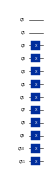

Running QPE circuit with statevector simulator...
Bitstring: 001111, Energy: -84.149803 MeV, Probability: 0.372280
Bitstring: 010111, Energy: -81.344810 MeV, Probability: 0.195685
Bitstring: 110111, Energy: -82.747307 MeV, Probability: 0.132443
Bitstring: 100011, Energy: -68.722339 MeV, Probability: 0.079262
Bitstring: 011111, Energy: -86.954797 MeV, Probability: 0.045281
Bitstring: 010011, Energy: -70.124836 MeV, Probability: 0.036139
Bitstring: 110011, Energy: -71.527333 MeV, Probability: 0.035362
Bitstring: 000111, Energy: -78.539816 MeV, Probability: 0.017835
Bitstring: 011011, Energy: -75.734823 MeV, Probability: 0.012287
Bitstring: 111101, Energy: -65.917346 MeV, Probability: 0.009393


In [28]:
# Set parameters for QPE
n_ancilla = 6; trotter_steps = 6

print("Emin:", 2 * np.pi / (-delta_t))
# Read Hamiltonian & M-scheme encoding
if target == "valence":
    hamil = Hamiltonian(filename_snt, Z-Zc, N-Nc)
else:
    hamil = Hamiltonian(filename_snt, Z, N, ncsm=True, 
                        emax_truncate=emax, e3max=e3max, fn_3NF=fn_3NF)
hamil.get_mscheme_H(opform=True)
H_1b_p, H_1b_n, H_jz_p, H_jz_n, H_pp, H_nn, H_pn, H_3b = hamil.mapping_opform("Jordan-Wigner")

Hamil_mapped = 0 * H_1b_p 
if Z-Zc > 0:
    Hamil_mapped += H_1b_p
    if Z-Zc > 1:
        Hamil_mapped += H_pp

if N-Nc > 0:
    Hamil_mapped += H_1b_n
    if N-Nc > 1:
        Hamil_mapped += H_nn

if Z-Zc > 0 and N-Nc > 0:
    Hamil_mapped +=  H_pn

if target == "NN3NF":
    hamil.set_mscheme_3NF()
    H_3b = hamil.mapping_3NF_Mscheme()
    Hamil_mapped += H_3b

Hamil_mapped = Hamil_mapped.simplify()

n_qubit_p = hamil.n_qubits_p
n_qubit_n = hamil.n_qubits_n
n_qubit = hamil.n_qubits
print("n_qubit:", n_qubit, "(p:", n_qubit_p, ", n:", n_qubit_n, ")")

# Brute force diagonalization for comparison: `Diagonalize_Hamiltonian` in src/nuqulib/diagonalization.py
basis, Hsub, Ens_exact = Diagonalize_Hamiltonian(Hamil_mapped, hamil, Z, N, target_parity, Zc, Nc)

# QPE parts
if target == "valence":
    U_prep = QuantumCircuit(n_qubit)
    for q in qrange:
        U_prep.x(q)
else:
    U_prep = lowest_filling_ansatz(hamil, Z, N)


display(U_prep.draw(output="mpl", scale=0.2))

qc_QPE = circuit_my_QPE(n_ancilla, n_qubit, Hamil_mapped, U_prep, delta_t, trotter_order=2, trotter_steps=trotter_steps)
qc_sv = qc_QPE.remove_final_measurements(inplace=False)
qc_sv.save_statevector()

# Run Aer statevector simulator
print("Running QPE circuit with statevector simulator...")
sim = AerSimulator(method='statevector', device=device_type)
tqc = transpile(qc_sv, sim)
job = sim.run(tqc)
result = job.result()
psi_final = result.get_statevector(tqc)

# Get probabilities on ancilla register only
anc_idx = [qc_QPE.qubits.index(q) for q in qc_QPE.qregs[0]]
probs = psi_final.probabilities_dict(qargs=anc_idx)

list_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
summarized_probs = {} 
for bitstring_whole, p in list_probs:
    bitstring = bitstring_whole[:n_ancilla]
    if bitstring in summarized_probs:
        summarized_probs[bitstring] += p
    else:
        summarized_probs[bitstring] = p
list_probs = sorted(summarized_probs.items(), key=lambda x: x[1], reverse=True)

Energy_list = []
for bitstring, p in list_probs[:10]:
    energy =  2 * np.pi * int(bitstring[::-1], 2) / (-delta_t * (2**n_ancilla))
    Energy_list.append((energy, p))
    print(f"Bitstring: {bitstring}, Energy: {energy:.6f} MeV, Probability: {p:.6f}")

plot_spectrum(n_ancilla, delta_t, target, nuc, Energy_list, Ens_exact)